# Backtesting with zipline - Pipeline API with Custom Data

## Imports & Settings

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from pathlib import Path
from time import time

import numpy as np
import pandas as pd
import pandas_datareader.data as web
from logbook import Logger, StderrHandler, INFO, WARNING

from zipline import run_algorithm
from zipline.api import (attach_pipeline, pipeline_output,
                         date_rules, time_rules, record,
                         schedule_function, commission, slippage,
                         set_slippage, set_commission, set_max_leverage,
                         order_target, order_target_percent,
                         get_open_orders, cancel_order)
from zipline.data import bundles
from zipline.utils.run_algo import load_extensions
from zipline.pipeline import Pipeline, CustomFactor
from zipline.pipeline.data import Column, DataSet
from zipline.pipeline.domain import US_EQUITIES
from zipline.pipeline.filters import StaticAssets
from zipline.pipeline.loaders import USEquityPricingLoader
from zipline.pipeline.loaders.frame import DataFrameLoader
#from trading_calendars import get_calendar

import pyfolio as pf
from pyfolio.plotting import plot_rolling_returns, plot_rolling_sharpe
from pyfolio.timeseries import forecast_cone_bootstrap

from alphalens.tears import (create_returns_tear_sheet,
                             create_summary_tear_sheet,
                             create_full_tear_sheet)

from alphalens.performance import mean_return_by_quantile
from alphalens.plotting import plot_quantile_returns_bar
from alphalens.utils import get_clean_factor_and_forward_returns, rate_of_return

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_style('whitegrid')

np.random.seed(42)
idx = pd.IndexSlice

In [4]:
results_path = Path('results')

## Alphalens Analysis

In [5]:
#DATA_STORE = Path('..', 'data', 'assets.h5')
DATA_STORE = Path('..', 'data', 'nasdaq_data_yf.h5')

In [6]:
START = '2010'
END = '2025'


In [7]:
def get_trade_prices(tickers):
    #prices = (pd.read_hdf(DATA_STORE, 'quandl/wiki/prices').swaplevel().sort_index())
    prices = (pd.read_hdf(DATA_STORE, 'nasdaq/price').swaplevel().sort_index())
    prices.index.names = ['symbol', 'date']
    prices = prices.loc[idx[tickers, START:END], 'open']
    return (prices
            .unstack('symbol')
            .sort_index()
            .shift(-1)
            .tz_localize('UTC'))

In [8]:
#predictions = (pd.read_hdf(results_path / 'test_preds.h5', 'predictions')
predictions = (pd.read_hdf(results_path / 'test_preds_2025-05-02.h5', 'predictions')
               .iloc[:, :3]
               .mean(1)
               .to_frame('prediction'))

In [9]:
predictions.sort_index(level=1)

,,prediction
symbol,date,
AAOI,2021-12-29,-0.000792
AAON,2021-12-29,0.000613
AAPL,2021-12-29,-0.005836
ACB,2021-12-29,-0.000847
ACGL,2021-12-29,-0.000019
...,...,...
ZTEK,2023-12-29,-0.001140
ZUMZ,2023-12-29,0.000988
ZVRA,2023-12-29,-0.002063


In [10]:
factor = (predictions
          .unstack('symbol')
          .asfreq('D')
          .dropna(how='all')
          .stack()
          .tz_localize('UTC', level='date')
          .sort_index())
tickers = factor.index.get_level_values('symbol').unique()

In [11]:
trade_prices = get_trade_prices(tickers)

In [12]:
len(factor)

453597

In [13]:
# If the code complains about factor, do this
factor = factor.unstack('symbol').resample('D').last().stack('symbol')
len(factor)

453597

In [14]:
factor_data = get_clean_factor_and_forward_returns(factor=factor,
                                                   prices=trade_prices,
                                                   quantiles=5,
                                                   max_loss=0.3,
                                                   periods=(1, 5, 10, 21)).sort_index()
factor_data.info()

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 30.0%, not exceeded: OK!
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 453597 entries, (Timestamp('2021-12-29 00:00:00+0000', tz='UTC'), 'AAOI') to (Timestamp('2023-12-29 00:00:00+0000', tz='UTC'), 'ZYXI')
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   1D               453597 non-null  float64
 1   7D               453597 non-null  float64
 2   14D              453597 non-null  float64
 3   30D              453597 non-null  float64
 4   factor           453597 non-null  float32
 5   factor_quantile  453597 non-null  int64  
dtypes: float32(1), float64(4), int64(1)
memory usage: 20.9+ MB


Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.100628,0.006992,-0.002506,0.005221,90720,20.000132
2,-0.037869,0.009365,-0.000684,0.003259,90720,20.000132
3,-0.030179,0.011676,0.000148,0.002638,90718,19.999691
4,-0.023470,0.015608,0.000930,0.002259,90719,19.999912
5,-0.015739,0.130027,0.002833,0.003950,90720,20.000132


Returns Analysis


,1D,7D,14D,30D
Ann. alpha,0.207,0.153,0.127,0.088
beta,0.125,0.123,0.167,0.153
Mean Period Wise Return Top Quantile (bps),4.353,4.329,3.294,2.373
Mean Period Wise Return Bottom Quantile (bps),-4.522,-3.190,-2.206,-1.688
Mean Period Wise Spread (bps),8.875,7.495,5.476,4.031


Information Analysis


,1D,7D,14D,30D
IC Mean,0.003,0.020,0.020,0.019
IC Std.,0.100,0.099,0.099,0.101
Risk-Adjusted IC,0.033,0.200,0.202,0.191
t-stat(IC),NaN,NaN,NaN,NaN
p-value(IC),NaN,NaN,NaN,NaN
IC Skew,NaN,NaN,NaN,NaN
IC Kurtosis,NaN,NaN,NaN,NaN


Turnover Analysis


,1D,7D,14D,30D
Quantile 1 Mean Turnover,0.443,0.552,0.626,0.655
Quantile 2 Mean Turnover,0.667,0.721,0.749,0.768
Quantile 3 Mean Turnover,0.704,0.748,0.766,0.778
Quantile 4 Mean Turnover,0.673,0.717,0.743,0.762
Quantile 5 Mean Turnover,0.467,0.569,0.647,0.687


,1D,7D,14D,30D
Mean Factor Rank Autocorrelation,0.604,0.44,0.311,0.251


<Figure size 640x480 with 0 Axes>

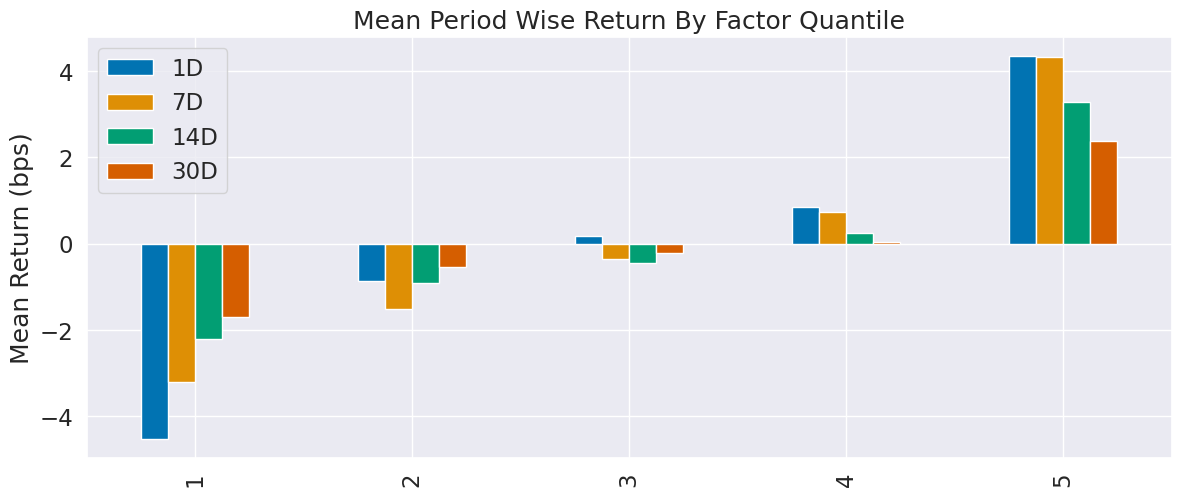

In [15]:
create_summary_tear_sheet(factor_data)

### Load zipline extensions

Only need this in notebook to find bundle.

In [16]:
load_extensions(default=True,
                extensions=[],
                strict=True,
                environ=None)

In [17]:
log_handler = StderrHandler(format_string='[{record.time:%Y-%m-%d %H:%M:%S.%f}]: ' +
                            '{record.level_name}: {record.func_name}: {record.message}',
                            level=WARNING)
log_handler.push_application()
log = Logger('Algorithm')

## Algo Params

In [18]:
N_LONGS = 25
N_SHORTS = 25
MIN_POSITIONS = 10

## Load Data

### Quandl Wiki Bundel

In [19]:
bundle_data = bundles.load('quandl')

### ML Predictions

In [20]:
def load_predictions(bundle):
    #predictions = (pd.read_hdf(results_path / 'test_preds.h5', 'predictions')
    predictions = (pd.read_hdf(results_path / 'test_preds_2025-05-02.h5', 'predictions')

                   .iloc[:, :3]
                   .mean(1)
                   .to_frame('prediction'))
    tickers = predictions.index.get_level_values('symbol').unique().tolist()

    assets = bundle.asset_finder.lookup_symbols(tickers, as_of_date=None)
    predicted_sids = pd.Index([asset.sid for asset in assets],dtype=np.int64)
    ticker_map = dict(zip(tickers, predicted_sids))

    return (predictions
            .unstack('symbol')
            .rename(columns=ticker_map)
            .prediction
            #.tz_localize('UTC')), assets
            .tz_localize(None)), assets

In [21]:
predictions, assets = load_predictions(bundle_data)

SymbolNotFound: Symbol 'ACB' was not found.

In [ ]:
predictions

symbol,0,2,4,7,8,13,19,20,24,30,...,2340,2355,2595,2713,2758,2785,2953,597,2531,2779
date,,,,,,,,,,,,,,,,,,,,,
2017-08-30,-0.000777,-0.000520,0.000009,0.000817,0.000978,-0.003457,-0.001051,-0.000755,-0.001790,-0.002428,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-08-31,-0.001511,0.000180,0.000931,0.002290,-0.000347,-0.001872,0.000377,-0.001466,-0.001685,-0.001683,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-01,0.000928,-0.000578,0.001852,0.001341,-0.000308,0.003057,0.003071,0.000756,-0.000117,-0.000224,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-05,-0.000828,-0.000573,-0.001065,-0.000308,-0.000276,-0.002219,0.000272,-0.000696,-0.001076,-0.002147,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-06,-0.001746,-0.001868,-0.000326,-0.000903,-0.001324,-0.001068,-0.000104,-0.001493,-0.000601,-0.002108,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-02-24,-0.000068,-0.000604,-0.001314,-0.001138,-0.000361,-0.001248,-0.001516,-0.001136,-0.001526,-0.001190,...,0.000810,-0.000057,-0.000328,0.001187,-0.000072,-0.000183,0.001219,-0.001139,-0.000468,NaN
2015-02-25,0.000041,-0.001194,-0.001482,-0.001244,-0.001783,-0.000729,-0.001389,-0.000967,-0.000966,-0.001899,...,0.000162,-0.000636,-0.000131,-0.000182,-0.001143,0.000134,0.000854,-0.001660,-0.000933,NaN
2015-02-26,0.000041,-0.000934,-0.001936,-0.002033,-0.000809,-0.000564,-0.001370,-0.000840,-0.002346,-0.001641,...,-0.000276,-0.001535,-0.000758,-0.001923,-0.001320,0.000455,-0.000301,-0.001471,-0.002966,NaN


In [ ]:
predictions.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 756 entries, 2017-08-30 to 2015-03-02
Columns: 993 entries, 0 to 2779
dtypes: float32(993)
memory usage: 2.9 MB


### Define Custom Dataset

In [ ]:
class SignalData(DataSet):
    predictions = Column(dtype=float)
    domain = US_EQUITIES

### Define Pipeline Loaders

In [ ]:
signal_loader = {SignalData.predictions:
                     DataFrameLoader(SignalData.predictions, predictions)}

## Pipeline Setup

### Custom ML Factor

In [ ]:
class MLSignal(CustomFactor):
    """Converting signals to Factor
        so we can rank and filter in Pipeline"""
    inputs = [SignalData.predictions]
    window_length = 1

    def compute(self, today, assets, out, predictions):
        out[:] = predictions

### Create Pipeline

In [ ]:
def compute_signals():
    signals = MLSignal()
    return Pipeline(columns={
        'longs' : signals.top(N_LONGS, mask=signals > 0),
        'shorts': signals.bottom(N_SHORTS, mask=signals < 0)},
            screen=StaticAssets(assets))

## Initialize Algorithm

In [ ]:
def initialize(context):
    """
    Called once at the start of the algorithm.
    """
    context.longs = context.shorts = None
    set_slippage(slippage.FixedSlippage(spread=0.00))
#     set_commission(commission.PerShare(cost=0.001, min_trade_cost=0))

    schedule_function(rebalance,
                      date_rules.every_day(),
                      time_rules.market_open(hours=1, minutes=30))

    schedule_function(record_vars,
                      date_rules.every_day(),
                      time_rules.market_close())

    pipeline = compute_signals()
    attach_pipeline(pipeline, 'signals')

### Get daily Pipeline results

In [ ]:
def before_trading_start(context, data):
    """
    Called every day before market open.
    """
    output = pipeline_output('signals')
    longs = pipeline_output('signals').longs.astype(int)
    shorts = pipeline_output('signals').shorts.astype(int)
    holdings = context.portfolio.positions.keys()
    
    if longs.sum() > MIN_POSITIONS and shorts.sum() > MIN_POSITIONS:
        context.longs = longs[longs!=0].index
        context.shorts = shorts[shorts!=0].index
        context.divest = holdings - set(context.longs) - set(context.shorts)
    else:
        context.longs = context.shorts = pd.Index([])
        context.divest = set(holdings)

## Define Rebalancing Logic

In [ ]:
def rebalance(context, data):
    """
    Execute orders according to schedule_function() date & time rules.
    """
    
    for symbol, open_orders in get_open_orders().items():
        for open_order in open_orders:
            cancel_order(open_order)
          
    for stock in context.divest:
        order_target(stock, target=0)
    
#     log.warning('{} {:,.0f}'.format(len(context.portfolio.positions), context.portfolio.portfolio_value))
    if not (context.longs.empty and context.shorts.empty):
        for stock in context.shorts:
            order_target_percent(stock, -1 / len(context.shorts))
        for stock in context.longs:
            order_target_percent(stock, 1 / len(context.longs))

## Record Data Points

In [ ]:
def record_vars(context, data):
    """
    Plot variables at the end of each day.
    """
    record(leverage=context.account.leverage,
           longs=context.longs,
           shorts=context.shorts)

## Run Algorithm

In [ ]:
dates = predictions.index.get_level_values('date')
start_date, end_date = dates.min(), dates.max()

In [ ]:
print('Start: {}\nEnd:   {}'.format(start_date.date(), end_date.date()))

Start: 2014-11-28
End:   2017-11-29


In [ ]:
cash = 1e5

In [ ]:
start = time()
results = run_algorithm(start=start_date,
                        end=end_date,
                        initialize=initialize,
                        before_trading_start=before_trading_start,
                        capital_base=cash,
                        data_frequency='daily',
                        bundle='quandl',
                        custom_loader=signal_loader)

print('Duration: {:.2f}s'.format(time() - start))

Duration: 84.26s


## PyFolio Analysis

In [ ]:
returns, positions, transactions = pf.utils.extract_rets_pos_txn_from_zipline(results)

In [ ]:
returns

2014-11-28 00:00:00+00:00    0.000000
2014-12-01 00:00:00+00:00   -0.000103
2014-12-02 00:00:00+00:00   -0.002206
2014-12-03 00:00:00+00:00    0.003187
2014-12-04 00:00:00+00:00   -0.013601
                               ...   
2017-11-22 00:00:00+00:00    0.025042
2017-11-24 00:00:00+00:00   -0.005351
2017-11-27 00:00:00+00:00    0.002634
2017-11-28 00:00:00+00:00    0.000128
2017-11-29 00:00:00+00:00    0.025143
Name: returns, Length: 757, dtype: float64

In [ ]:
import yfinance as yf
from datetime import datetime
# Download S&P 500 index data (ticker: ^GSPC)
yesterday = (datetime.today()-pd.DateOffset(1)).strftime('%Y-%m-%d')
benchmark = yf.download('^GSPC', start='2010-01-01', end=yesterday,auto_adjust=False)['Adj Close']
benchmark = benchmark.pct_change().tz_localize('UTC')

[*********************100%***********************]  1 of 1 completed


In [ ]:
benchmark_fred = web.DataReader('SP500', 'fred', '2014', '2018').squeeze()
benchmark_fred = benchmark_fred.pct_change().tz_localize('UTC')
benchmark=benchmark.stack().reset_index(level=1,drop=True)

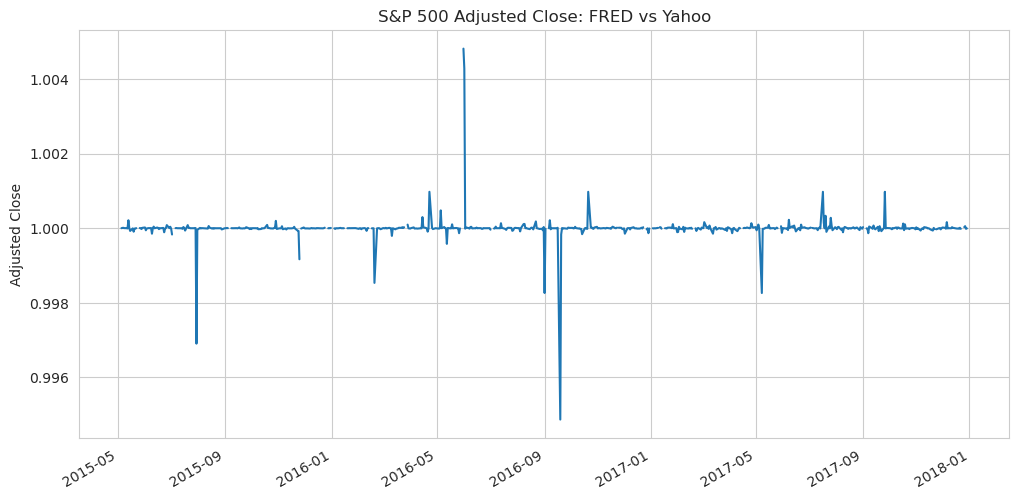

In [ ]:
# Plot FRED and YF adj close to see if they match
combined = pd.DataFrame({
    'FRED': benchmark_fred,
    'Yahoo': benchmark
})#.dropna()
ratio = combined['Yahoo']/combined['FRED']
# Plot
ratio.plot(figsize=(12, 6), title='S&P 500 Adjusted Close: FRED vs Yahoo')
plt.ylabel('Adjusted Close')
plt.grid(True)
plt.show()

In [ ]:
returns

2014-11-28 00:00:00+00:00    0.000000
2014-12-01 00:00:00+00:00   -0.000103
2014-12-02 00:00:00+00:00   -0.002206
2014-12-03 00:00:00+00:00    0.003187
2014-12-04 00:00:00+00:00   -0.013601
                               ...   
2017-11-22 00:00:00+00:00    0.025042
2017-11-24 00:00:00+00:00   -0.005351
2017-11-27 00:00:00+00:00    0.002634
2017-11-28 00:00:00+00:00    0.000128
2017-11-29 00:00:00+00:00    0.025143
Name: returns, Length: 757, dtype: float64

In [ ]:
benchmark.tail(10)

Date
2025-04-16 00:00:00+00:00   -0.022408
2025-04-17 00:00:00+00:00    0.001327
2025-04-21 00:00:00+00:00   -0.023567
2025-04-22 00:00:00+00:00    0.025117
2025-04-23 00:00:00+00:00    0.016661
2025-04-24 00:00:00+00:00    0.020259
2025-04-25 00:00:00+00:00    0.007373
2025-04-28 00:00:00+00:00    0.000641
2025-04-29 00:00:00+00:00    0.005802
2025-04-30 00:00:00+00:00    0.001480
dtype: float64

### Custom Plots

In [ ]:
LIVE_DATE = '2016-11-30'
#LIVE_DATE = '2016-11-30'

In [ ]:
# FIXME hardcoded date, it should go down to 2014
#returns = returns[returns.index > '2015-04-23']
returns.head(10)

2014-11-28 00:00:00+00:00    0.000000
2014-12-01 00:00:00+00:00   -0.000103
2014-12-02 00:00:00+00:00   -0.002206
2014-12-03 00:00:00+00:00    0.003187
2014-12-04 00:00:00+00:00   -0.013601
2014-12-05 00:00:00+00:00    0.003749
2014-12-08 00:00:00+00:00   -0.046712
2014-12-09 00:00:00+00:00    0.039601
2014-12-10 00:00:00+00:00   -0.037252
2014-12-11 00:00:00+00:00   -0.015886
Name: returns, dtype: float64

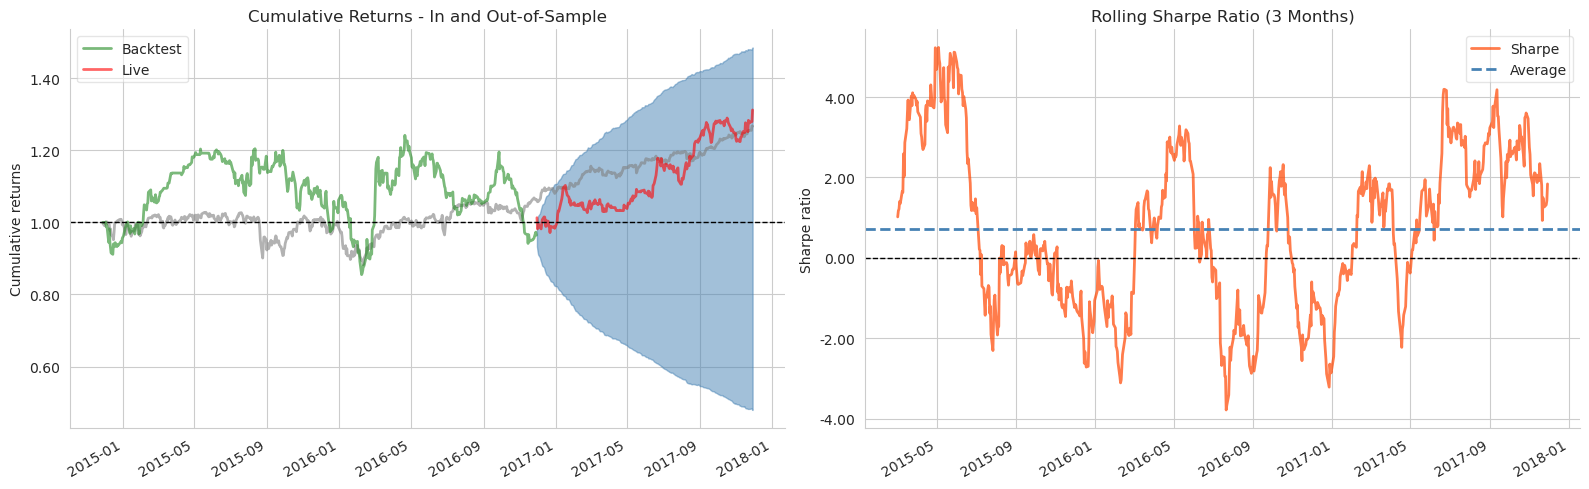

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(16, 5))
plot_rolling_returns(returns,
                     factor_returns=benchmark,
                     live_start_date=LIVE_DATE,
                     logy=False,
                     cone_std=2,
                     legend_loc='best',
                     volatility_match=False,
                     cone_function=forecast_cone_bootstrap,
                     ax=axes[0])
plot_rolling_sharpe(returns, ax=axes[1], rolling_window=63)
axes[0].set_title('Cumulative Returns - In and Out-of-Sample')
axes[1].set_title('Rolling Sharpe Ratio (3 Months)')
sns.despine()
fig.tight_layout()
fig.savefig((results_path / 'pyfolio_out_of_sample').as_posix(), dpi=300)

### Tear Sheets

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,28.99,2015-08-12,2016-02-08,2016-04-14,177
1,24.15,2016-04-21,2016-11-15,2017-09-05,359
2,10.71,2015-05-12,2015-07-27,2015-08-12,67
3,8.94,2014-12-03,2014-12-15,2015-01-09,28
4,5.07,2017-10-17,2017-11-07,2017-11-29,32


Stress Events,mean,min,max
Fall2015,-0.03%,-2.59%,3.18%
New Normal,0.05%,-5.89%,7.40%


Top 10 long positions of all time,max
sid,
SWN,9.69%
HRTX,8.78%
NKTR,8.66%
VRX,8.62%
IMMU,8.61%
HZNP,8.59%
AMD,8.53%
RH,8.49%
EXAS,8.47%


Top 10 short positions of all time,max
sid,
FIZZ,-9.98%
EXEL,-9.60%
HZNP,-9.54%
QLYS,-9.41%
OAS,-9.40%
SMTC,-9.36%
KOS,-9.30%
LGND,-9.29%
NKTR,-9.28%


Top 10 positions of all time,max
sid,
FIZZ,9.98%
SWN,9.69%
EXEL,9.60%
HZNP,9.54%
QLYS,9.41%
OAS,9.40%
SMTC,9.36%
KOS,9.30%
LGND,9.29%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$44236.71,$-32993.30,$77230.01
Gross profit,$1183034.97,$516959.14,$666075.83
Gross loss,$-1138798.26,$-549952.44,$-588845.82
Profit factor,$1.04,$0.94,$1.13
Avg. trade net profit,$1.84,$-2.65,$6.63
Avg. winning trade,$98.55,$87.87,$108.82
Avg. losing trade,$-95.46,$-84.93,$-107.97
Ratio Avg. Win:Avg. Loss,$1.03,$1.03,$1.01
Largest winning trade,$3807.70,$3807.70,$3625.00
Largest losing trade,$-2352.96,$-2352.96,$-2168.12


Duration stats,All trades,Short trades,Long trades
Avg duration,3 days 06:54:42.648424199,3 days 03:10:50.177951109,3 days 10:53:45.071606422
Median duration,2 days 00:00:00,2 days 00:00:00,3 days 00:00:00
Longest duration,256 days 23:00:00,38 days 01:00:00,256 days 23:00:00
Shortest duration,0 days 03:00:01,0 days 03:00:01,0 days 03:00:01


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,0.00%,-0.00%,0.01%
Avg returns winning,0.09%,0.08%,0.10%
Avg returns losing,-0.09%,-0.08%,-0.10%
Median returns all round_trips,0.00%,-0.00%,0.00%
Median returns winning,0.05%,0.05%,0.06%
Median returns losing,-0.05%,-0.05%,-0.06%
Largest winning trade,3.24%,3.24%,3.08%
Largest losing trade,-1.90%,-1.90%,-1.90%


Symbol stats,A,AAL,AAN,AAP,AAPL,ABC,ABMD,ABT,ACC,ACGL,ACIW,ACM,ACN,ACXM,ADBE,ADI,ADM,ADP,ADS,ADSK,AEE,AEL,AEO,AEP,AES,AET,AFG,AFL,AFSI,AGCO,AGN,AGNC,AGO,AIG,AIT,AIV,AIZ,AJG,AKAM,AL,ALB,ALE,ALGN,ALK,ALKS,ALL,ALNY,ALSN,ALXN,AMAT,AMCX,AMD,AME,AMED,AMG,AMGN,AMP,AMT,AMTD,AMZN,AN,ANAT,ANGI,ANSS,ANTM,AON,AOS,APA,APC,APD,APH,ARE,ARNC,ARRS,ARRY,ARW,ASGN,ASH,ATHN,ATI,ATO,ATR,ATVI,AVA,AVB,AVGO,AVT,AVX,AVY,AWI,AWK,AXP,AXS,AYI,AZO,AZPN,B,BA,BAC,BAH,BAX,BBBY,BBT,BBY,BC,BCO,BCPC,BDN,BDX,BECN,BEN,BERY,BG,BGCP,BID,BIDU,BIIB,BIO,BK,BKH,BKU,BLK,BLKB,BLL,BMRN,BMS,BMY,BOH,BOKF,BP,BPOP,BR,BRKR,BRO,BSX,BWA,BXP,BXS,BYD,C,CA,CACC,CACI,CAG,CAH,CASY,CAT,CATY,CAVM,CB,CBOE,CBRL,CBSH,CBT,CBU,CCE,CCI,CCK,CCL,CCMP,CDNS,CE,CELG,CERN,CF,CFR,CFX,CGNX,CHD,CHDN,CHE,CHFC,CHH,CHK,CHKP,CHRW,CHTR,CI,CIEN,CIM,CINF,CIT,CL,CLGX,CLH,CLNY,CLR,CLX,CMA,CMCSA,CME,CMG,CMI,CMS,CNA,CNC,CNK,CNO,CNP,CNX,COF,COG,COHR,COL,COLB,COLM,COO,COP,COR,COST,CPA,CPB,CPRT,CPT,CR,CREE,CRI,CRL,CRM,CSCO,CSGP,CSL,CSOD,CSX,CTAS,CTL,CTSH,CTXS,CUBE,CUZ,CVI,CVLT,CVS,CVX,CW,CXO,CXW,CY,CZR,D,DAL,DAN,DAR,DCI,DCT,DE,DECK,DEI,DFS,DG,DGX,DHI,DHR,DIS,DISCA,DISCK,DISH,DK,DKS,DLB,DLPH,DLR,DLTR,DLX,DNB,DNKN,DO,DOV,DOX,DPS,DPZ,DRE,DRI,DTE,DUK,DVA,DVN,DXCM,DY,EA,EBAY,ECL,ED,EDR,EEFT,EFX,EGN,EGP,EIX,EL,ELLI,ELS,EME,EMN,EMR,ENR,ENS,ENTG,EOG,EPAM,EPR,EQIX,EQR,EQT,ERIE,ES,ESGR,ESRX,ESS,ESV,ETFC,ETN,ETR,EV,EVR,EW,EWBC,EXAS,EXC,EXEL,EXP,EXPD,EXPE,EXR,F,FAF,FANG,FAST,FB,FBHS,FCFS,FCNCA,FCX,FDS,FDX,FE,FFBC,FFIN,FFIV,FHN,FICO,FIS,FISV,FITB,FIVE,FIZZ,FL,FLIR,FLO,FLR,FLS,FLT,FMC,FNB,FNF,FNGN,FOLD,FOX,FOXA,FR,FRT,FSLR,FTI,FTNT,FUL,FULT,G,GBCI,GD,GDOT,GE,GEO,GGG,GGP,GHC,GILD,GIS,GLNG,GLW,GM,GMED,GNRC,GNTX,GOLD,GOOGL,GPC,GPK,GPN,GPS,GPT,GRA,GRMN,GS,GT,GTT,GWR,GWRE,GWW,H,HAE,HAIN,HAL,HAS,HBAN,HBI,HCA,HCP,HCSG,HD,HE,HEI,HES,HFC,HHC,HI,HIG,HII,HIW,HLF,HOG,HOLX,HOMB,HON,HP,HPP,HPQ,HPT,HR,HRB,HRC,HRG,HRL,HRS,HRTX,HSIC,HST,HSY,HTA,HUM,HUN,HXL,HZNP,IART,IBKC,IBKR,IBM,IBOC,ICE,ICUI,IDA,IDCC,IDTI,IDXX,IFF,IGT,ILMN,IMMU,INCY,INGR,INTC,INTU,IP,IPG,IPGP,IR,IRM,IRWD,ISBC,ISRG,IT,ITT,ITW,IVZ,JBHT,JBL,JBLU,JBT,JCI,JCOM,JEC,JJSF,JKHY,JLL,JNJ,JNPR,JPM,JWN,K,KAR,KEX,KEY,KFY,KIM,KLAC,KMB,KMI,KMPR,KMT,KMX,KNX,KO,KORS,KOS,KR,KRC,KS,KSS,KSU,KW,L,LAMR,LANC,LAZ,LB,LBTYA,LDOS,LEA,LECO,LEG,LEN,LFUS,LGND,LH,LHCG,LHO,LII,LKQ,LLL,LLY,LM,LMT,LNC,LNG,LNT,LOGM,LOPE,LOW,LPLA,LPX,LRCX,LSI,LSTR,LTM,LUV,LVS,LYB,LYV,M,MA,MAA,MAC,MAN,MANH,MAR,MAS,MASI,MAT,MBFI,MCD,MCHP,MCK,MCO,MD,MDLZ,MDR,MDSO,MDT,MDU,MET,MFA,MGM,MHK,MIDD,MKC,MKL,MKSI,MKTX,MLM,MMC,MMM,MMS,MNST,MO,MOH,MORN,MOS,MPC,MPW,MPWR,MRK,MRO,MRVL,MS,MSA,MSCI,MSFT,MSG,MSI,MSM,MTB,MTD,MTDR,MTG,MTN,MTZ,MU,MUR,MXIM,MYL,NATI,NAV,NBIX,NBL,NCR,NDAQ,NDSN,NEE,NEM,NEOG,NEU,NFG,NFLX,NFX,NHI,NI,NJR,NKE,NKTR,NLSN,NLY,NOC,NOV,NOW,NRG,NSC,NSP,NTAP,NTRS,NUAN,NUE,NUS,NVDA,NVR,NWE,NWL,NXST,NYCB,NYT,O,OAS,OC,ODFL,OFC,OGE,OHI,OI,OKE,OLED,OLN,OMC,ONB,ORCL,ORI,ORLY,OSK,OXY,OZRK,PACW,PAG,PANW,PAYX,PB,PBCT,PBF,PCAR,PCG,PCH,PDCE,PEG,PEGA,PENN,PEP,PFE,PFG,PFPT,PG,PGR,PH,PHM,PII,PKG,PKI,PLD,PM,PNC,PNFP,PNM,PNR,PNW,PODD,POL,POOL,POR,POST,PPC,PPG,PPL,PRGO,PRI,PRLB,PRU,PSA,PSB,PSMT,PSX,PTEN,PVH,PWR,PX,PXD,QCOM,QEP,QGEN,QLYS,R,RBC,RCL,RDN,RE,REG,REGN,RES,RF,RGA,RGLD,RH,RHI,RHP,RHT,RIG,RJF,RL,RLGY,RLI,RLJ,RMD,RNR,ROL,ROLL,ROP,ROST,RP,RPAI,RPM,RRC,RS,RSG,RTN,RXN,RYN,S,SAM,SATS,SBAC,SBGI,SBNY,SBRA,SBUX,SCCO,SCG,SCHW,SCI,SE,SEB,SEE,SEIC,SF,SFLY,SFNC,SGEN,SGMS,SHO,SHOO,SHW,SIG,SIGI,SIRI,SIVB,SIX,SJI,SJM,SKX,SLAB,SLB,SLG,SLGN,SLM,SM,SMG,SMTC,SNA,SNH,SNPS,SNV,SNX,SO,SON,SPG,SPLK,SPR,SRCL,SRE,SSD,SSNC,STE,STI,STL,STLD,STMP,STT,STWD,STX,STZ,SUI,SWK,SWKS,SWN,SWX,SXT,SYK,SYMC,SYNT,SYY,T,TAL,TAP,TCBI,TCO,TDC,TDG,TDS,TDY,TECD,TECH,TEL,TER,TEX,TFSL,TFX,TGE,TGT,THC,THG,THO,THS,TIF,TJX,TKR,TMK,TMO,TMUS,TOL,TREX,TRGP,TRI,TRIP,TRMB,TRN,TROW,TRV,TSCO,TSLA,TSN,TSS,TTC,TTEK,TTWO,TWO,TXN,TXRH,TXT,TYL,UAA,UAL,UBNT,UBSI,UDR,UFS,UGI,UHAL,UHS,ULTA,ULTI,UMBF,UMPQ,UNF,UNH,UNM,UNP,UPS,URBN,URI,USB,USG,USM,USNA,UTHR,UTX,V,VAC,VAR,VC,VFC,VG,VIAB,VLO,VLY,VMC,VMI,VMW,VNO,VOD,VR,VRNT,VRSK,VRSN,VRTX,VRX,VSAT,VSH,VTR,VVC,VZ,WAB,WAFD,WAL,WAT,WBA,WBC,WBS,WCC,WCG,WCN,WDAY,WDC,

Profitability (PnL / PnL total) per name,
symbol,
EXEL,17.45%
ANGI,12.76%
TAL,12.66%
ARRY,11.43%
SGMS,6.05%
EXAS,6.03%
DKS,5.99%
CACC,5.95%
IMMU,5.69%


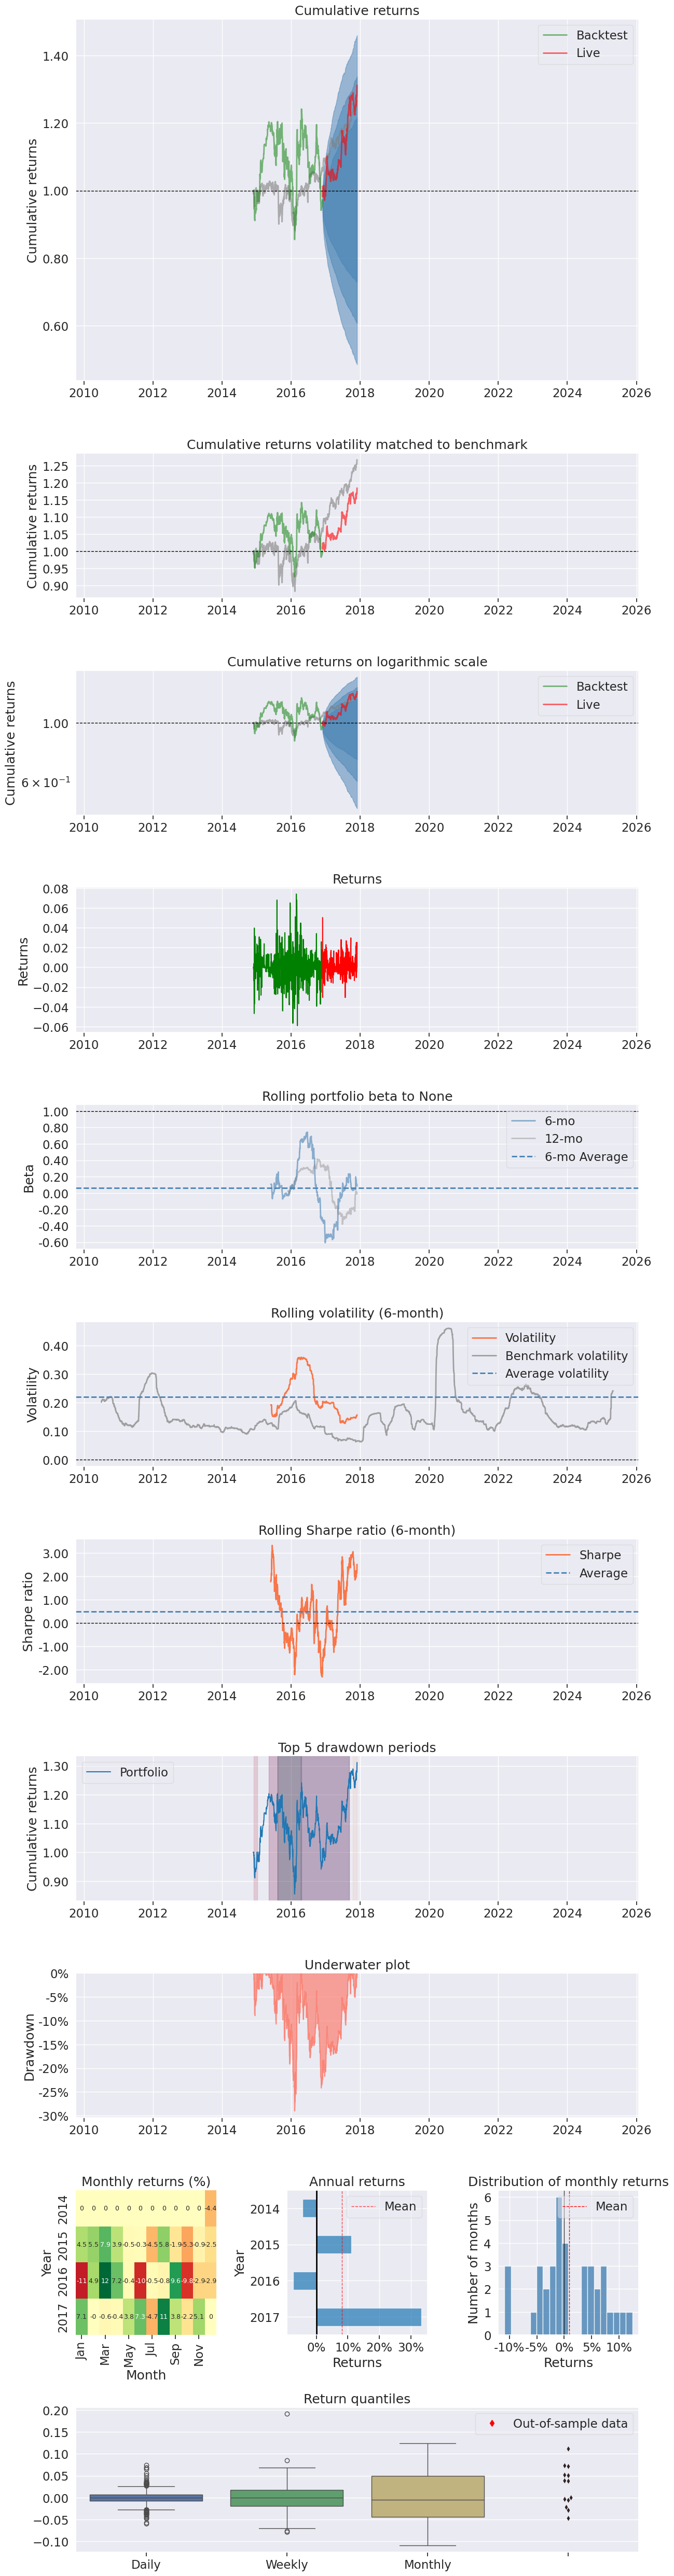

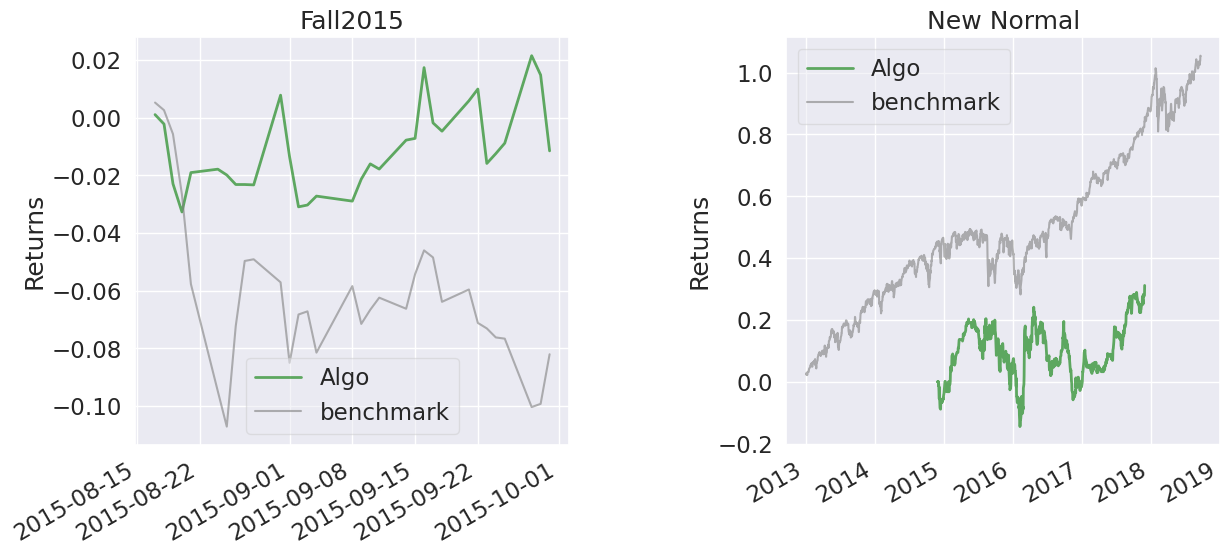

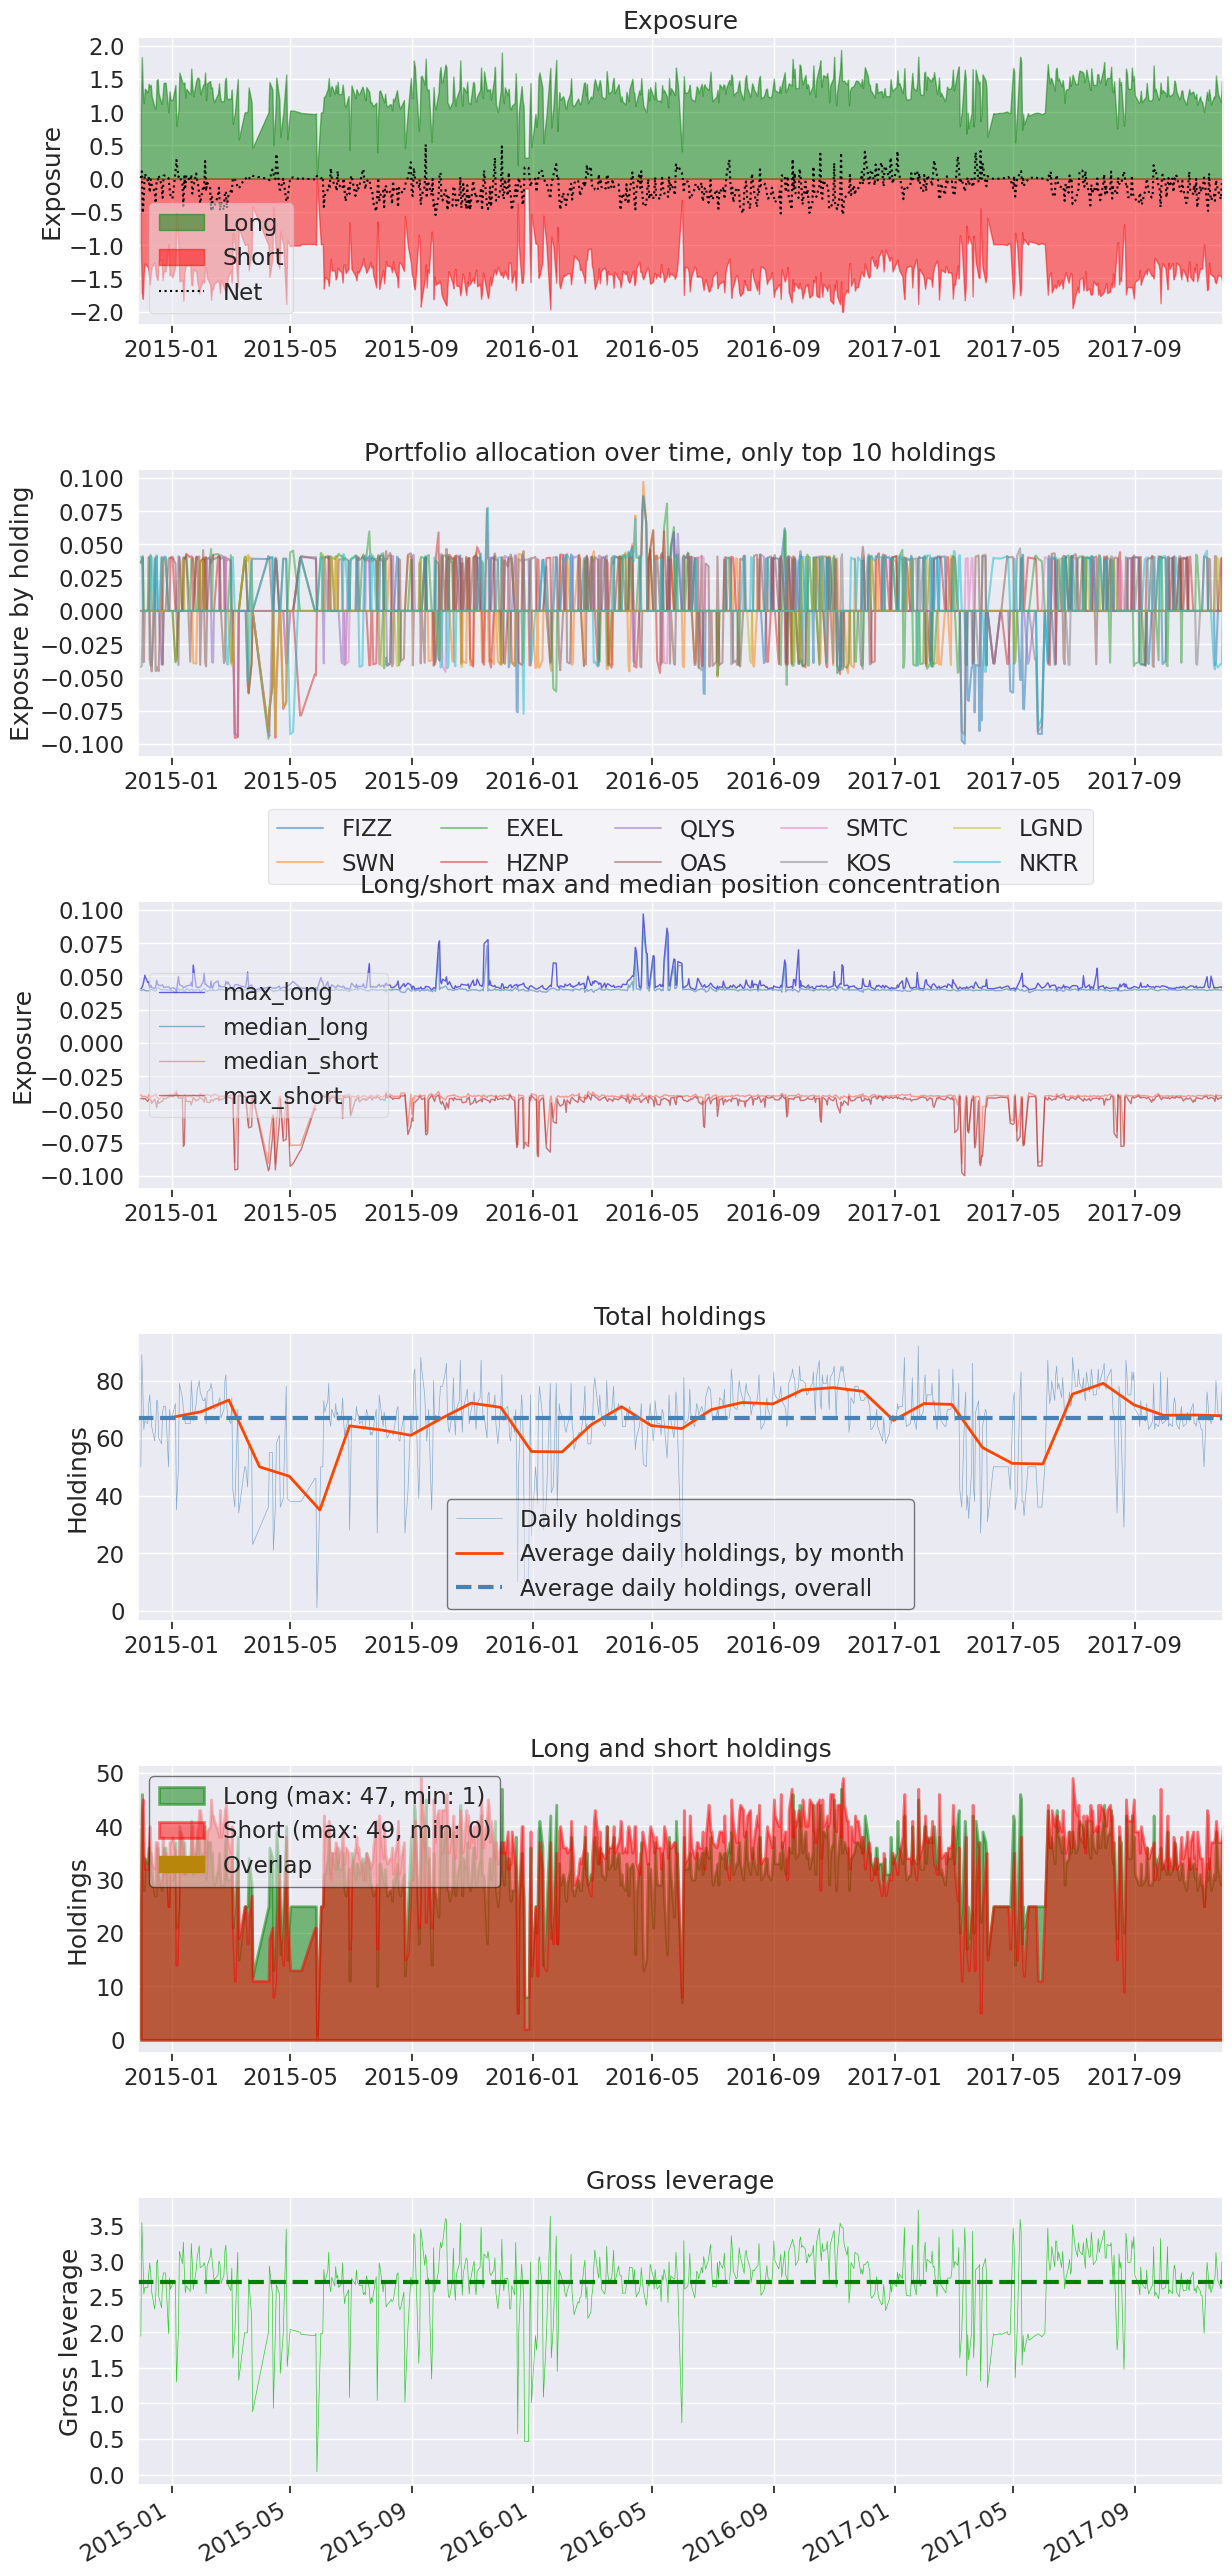

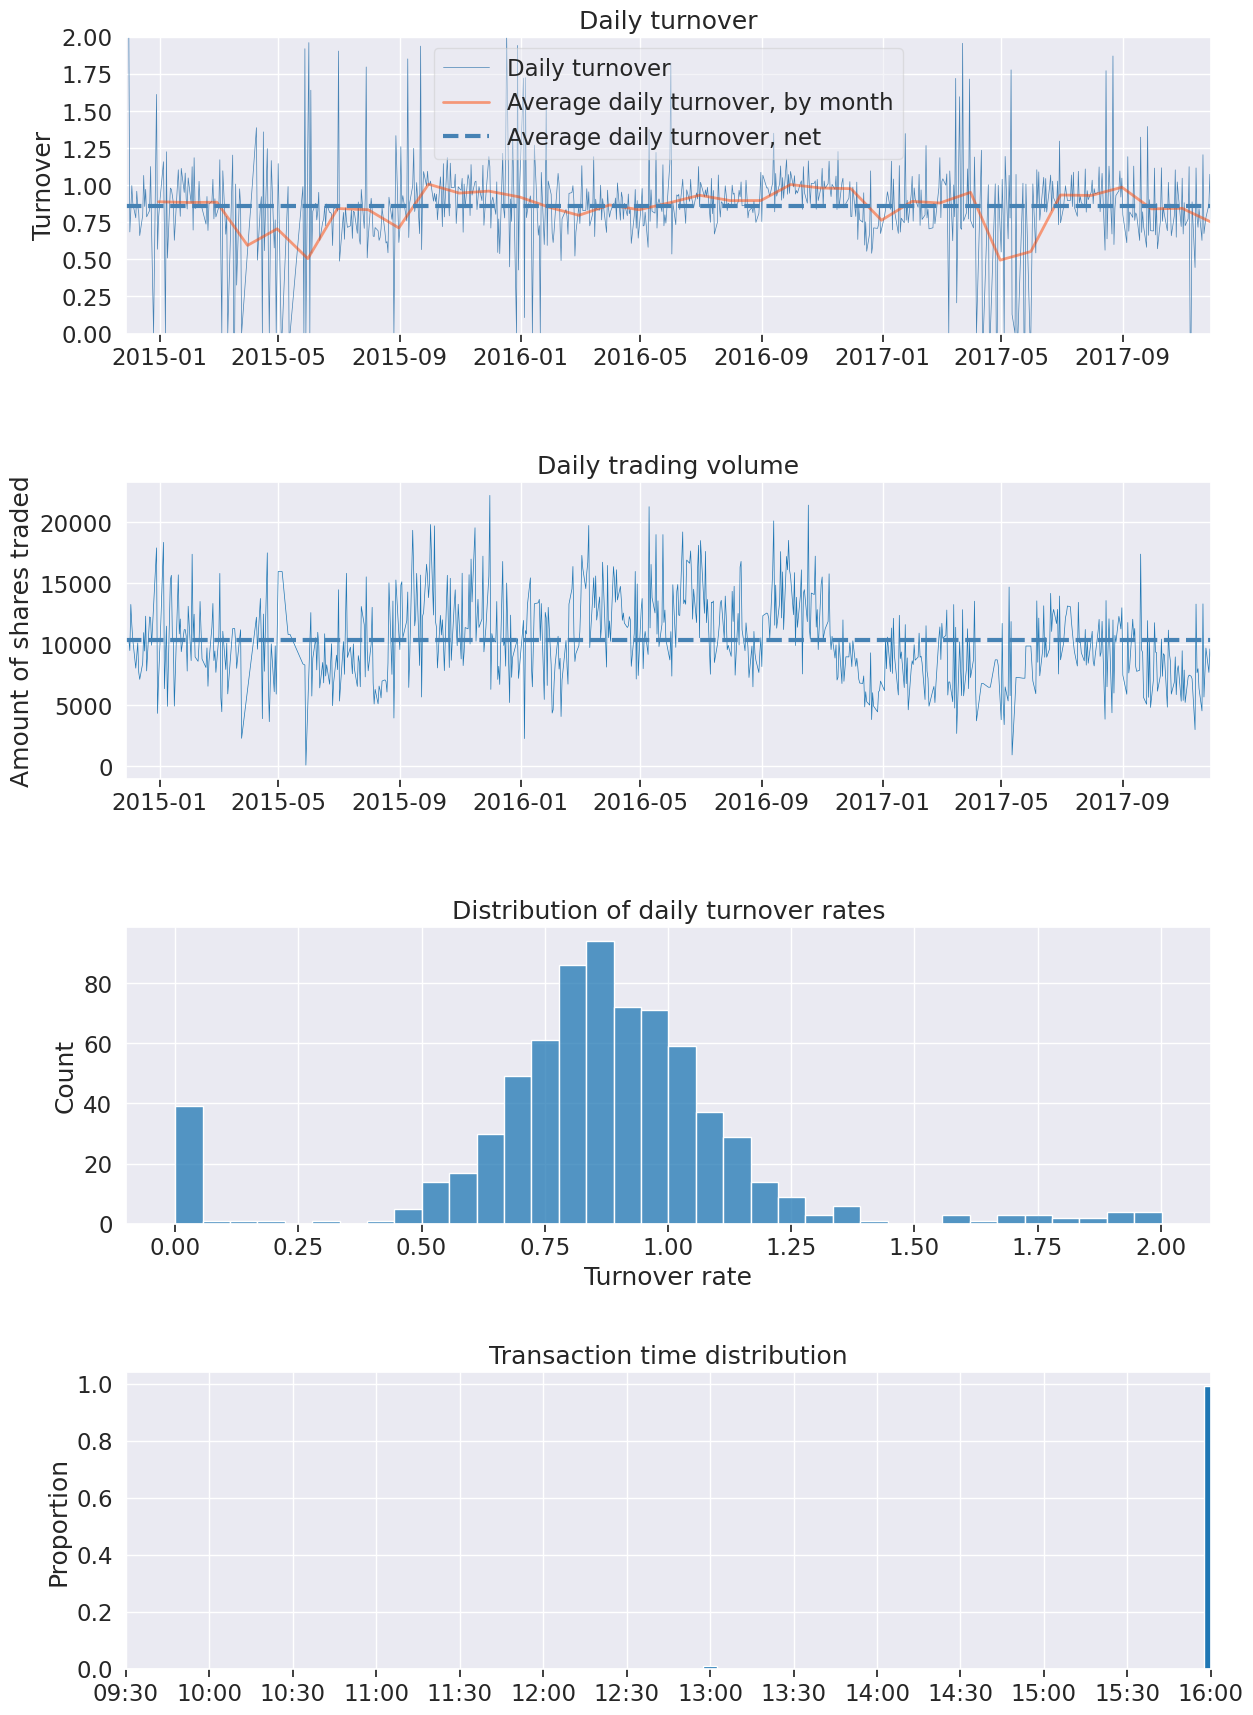

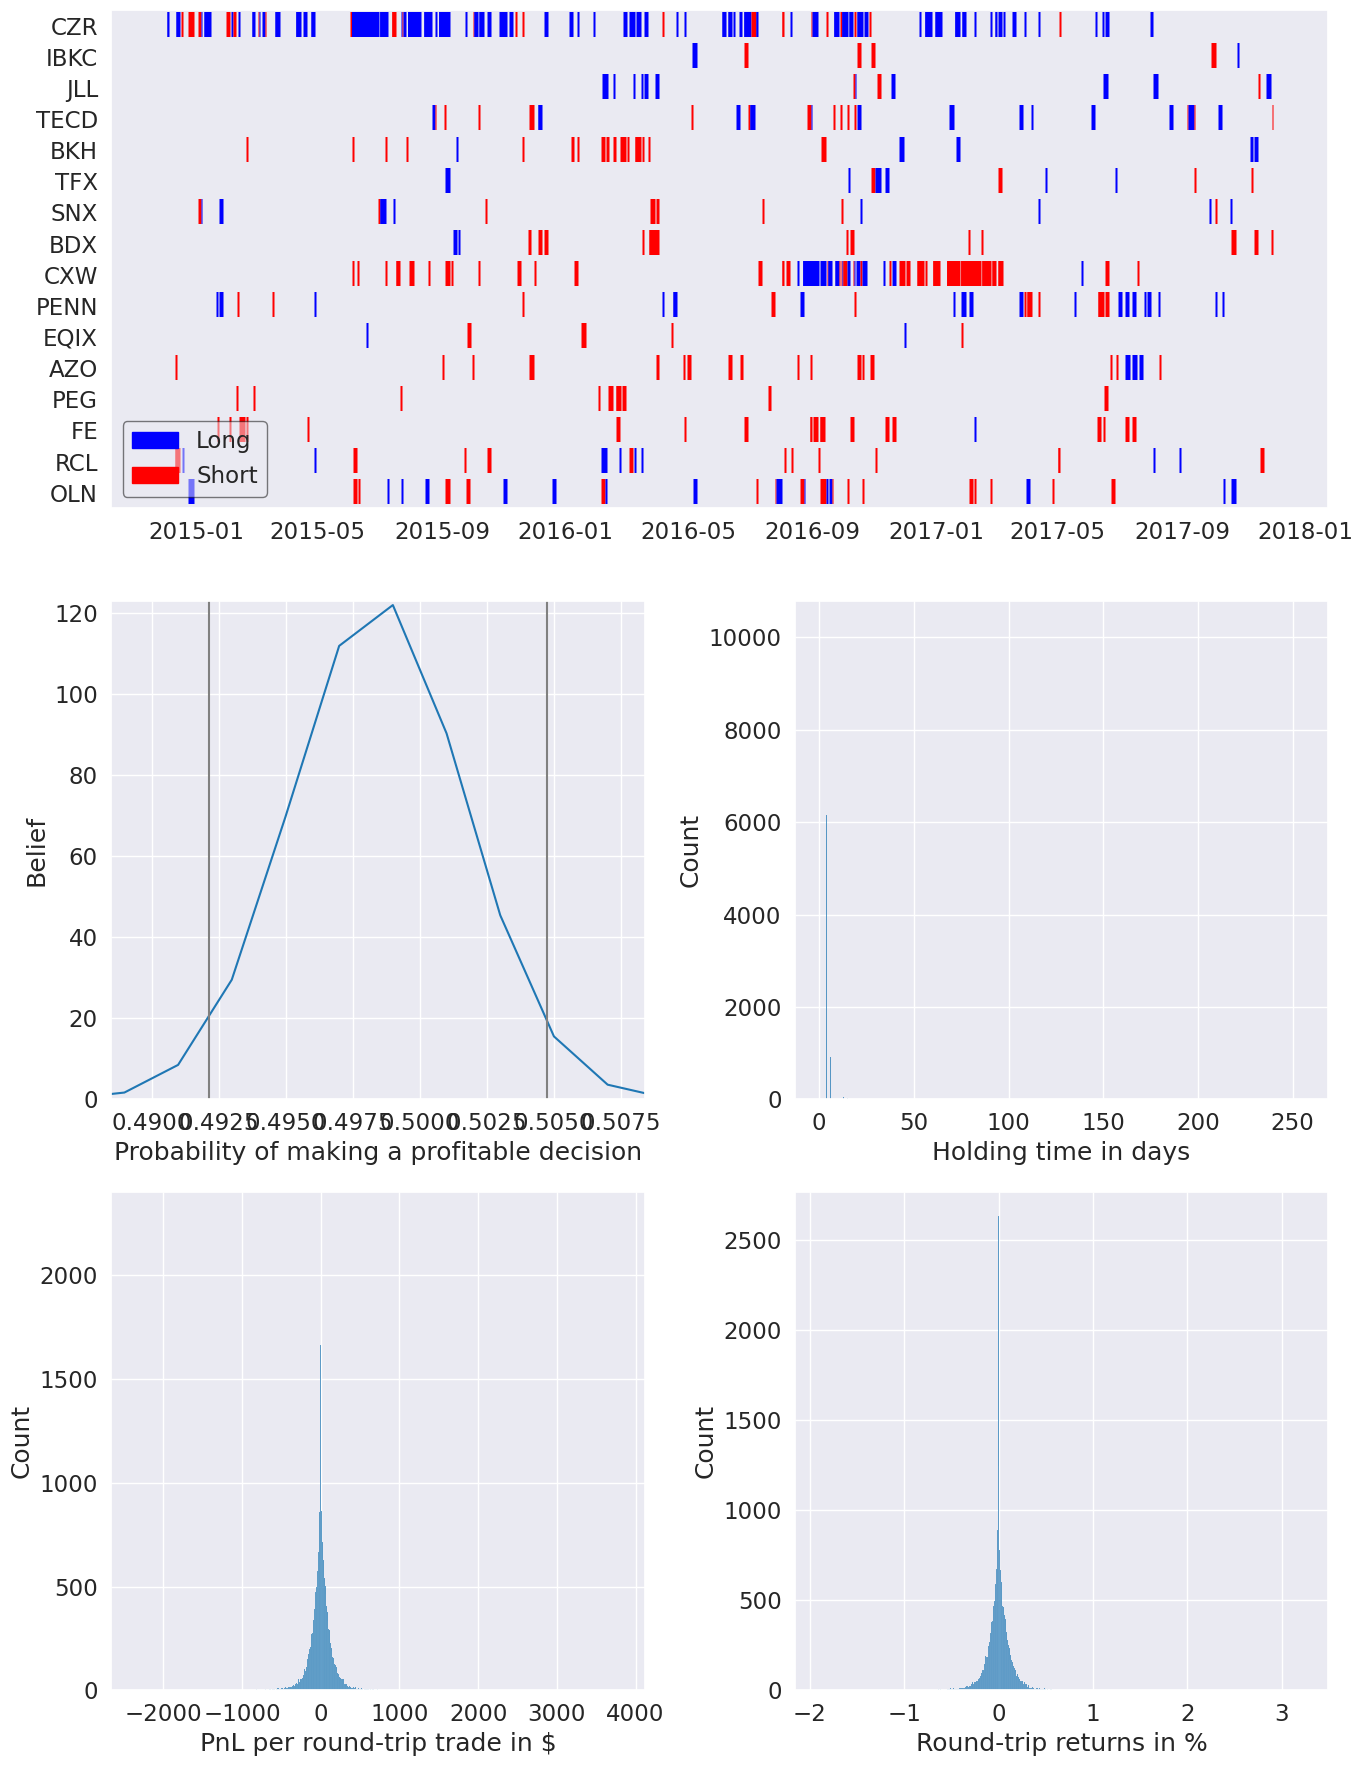

In [ ]:
pf.create_full_tear_sheet(returns, 
                          positions=positions, 
                          transactions=transactions,
                          benchmark_rets=benchmark,
                          live_start_date=LIVE_DATE, 
                          round_trips=True)